In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pykrige.ok import OrdinaryKriging

d = pd.read_csv('data PM10 mean 2025.csv', sep=";")

# Filtrer la France métropolitaine
d_metro = d[
    (d["validité"] == 1) &
    (d["Latitude"].between(41.0, 51.5)) &
    (d["Longitude"].between(-5.5, 10.0))
].dropna(subset=["Latitude", "Longitude", "valeur"])

print(d_metro["nom site"].nunique())

297


# Isotropie

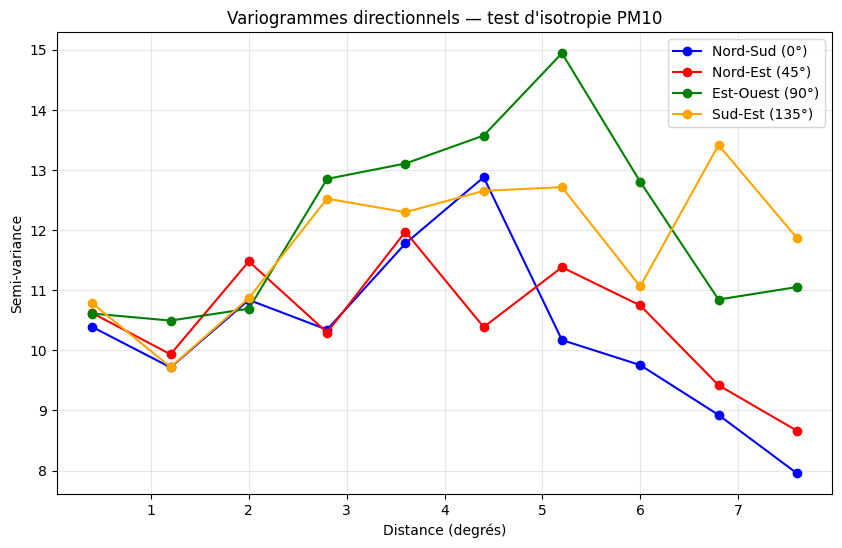

In [12]:
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

directions = [0, 45, 90, 135]
labels = ["Nord-Sud (0°)", "Nord-Est (45°)", "Est-Ouest (90°)", "Sud-Est (135°)"]
colors = ["blue", "red", "green", "orange"]

grid_lon = np.linspace(-5.5, 10.0, 100)
grid_lat = np.linspace(41.0, 51.5, 100)

lons = d_metro["Longitude"].values
lats = d_metro["Latitude"].values
vals = d_metro["valeur"].values

def variogramme_directionnel(lons, lats, vals, azimuth, tolerance=22.5, n_lags=10):
    coords = np.column_stack([lons, lats])
    bins = np.linspace(0, 8, n_lags + 1)
    gamma = []
    
    for k in range(n_lags):
        paires = []
        for i in range(len(coords)):
            for j in range(i+1, len(coords)):
                dx = coords[j,0] - coords[i,0]
                dy = coords[j,1] - coords[i,1]
                dist = np.sqrt(dx**2 + dy**2)
                angle = np.degrees(np.arctan2(dy, dx)) % 180
                
                if bins[k] <= dist < bins[k+1]:
                    if abs(angle - azimuth) <= tolerance or abs(angle - azimuth - 180) <= tolerance:
                        paires.append((vals[i] - vals[j])**2)
        
        gamma.append(np.mean(paires) / 2 if paires else np.nan)
    
    return (bins[:-1] + bins[1:]) / 2, gamma

plt.figure(figsize=(10, 6))
for azimuth, label, color in zip(directions, labels, colors):
    bins_mid, gamma = variogramme_directionnel(lons, lats, vals, azimuth)
    plt.plot(bins_mid, gamma, marker="o", label=label, color=color)

plt.xlabel("Distance (degrés)")
plt.ylabel("Semi-variance")
plt.title("Variogrammes directionnels — test d'isotropie PM10")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## NB LAGS

In [ ]:
import numpy as np
from scipy.spatial.distance import cdist

coords = d_metro[["Longitude", "Latitude"]].values
n = len(d_metro)

# --- Métriques de base ---
dists = cdist(coords, coords)
dist_max = dists.max()
dist_moy = dists[dists > 0].mean()
n_paires = n * (n - 1) // 2

# Lag size = distance moyenne aux 5 plus proches voisins
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=6).fit(coords)  # 6 car inclut le point lui-même
distances, _ = nbrs.kneighbors(coords)
dist_voisins = distances[:, 1:].mean()  # exclut distance à soi-même (=0)

dist_cible = dist_max / 2
nlags_r2 = int(dist_cible / dist_voisins)

print("=" * 50)
print("RÈGLE 2 & 3 — Couvrir la moitié du domaine")
print("=" * 50)
print(f"  Distance cible         : {dist_max:.2f} / 2 = {dist_cible:.2f}°")
print(f"  Lag size (voisins)     : {dist_voisins:.2f}°")
print(f"  nlags = {dist_cible:.2f} / {dist_voisins:.2f} = {nlags_r2}")
print(f"\n  ➜ nlags recommandé : {nlags_r2}")
print("=" * 50)

RÈGLE 2 & 3 — Couvrir la moitié du domaine
  Distance cible         : 15.14 / 2 = 7.57°
  Lag size (voisins)     : 0.39°
  nlags = 7.57 / 0.39 = 19

  ➜ nlags recommandé : 19


# Comparaison

### Isotropes

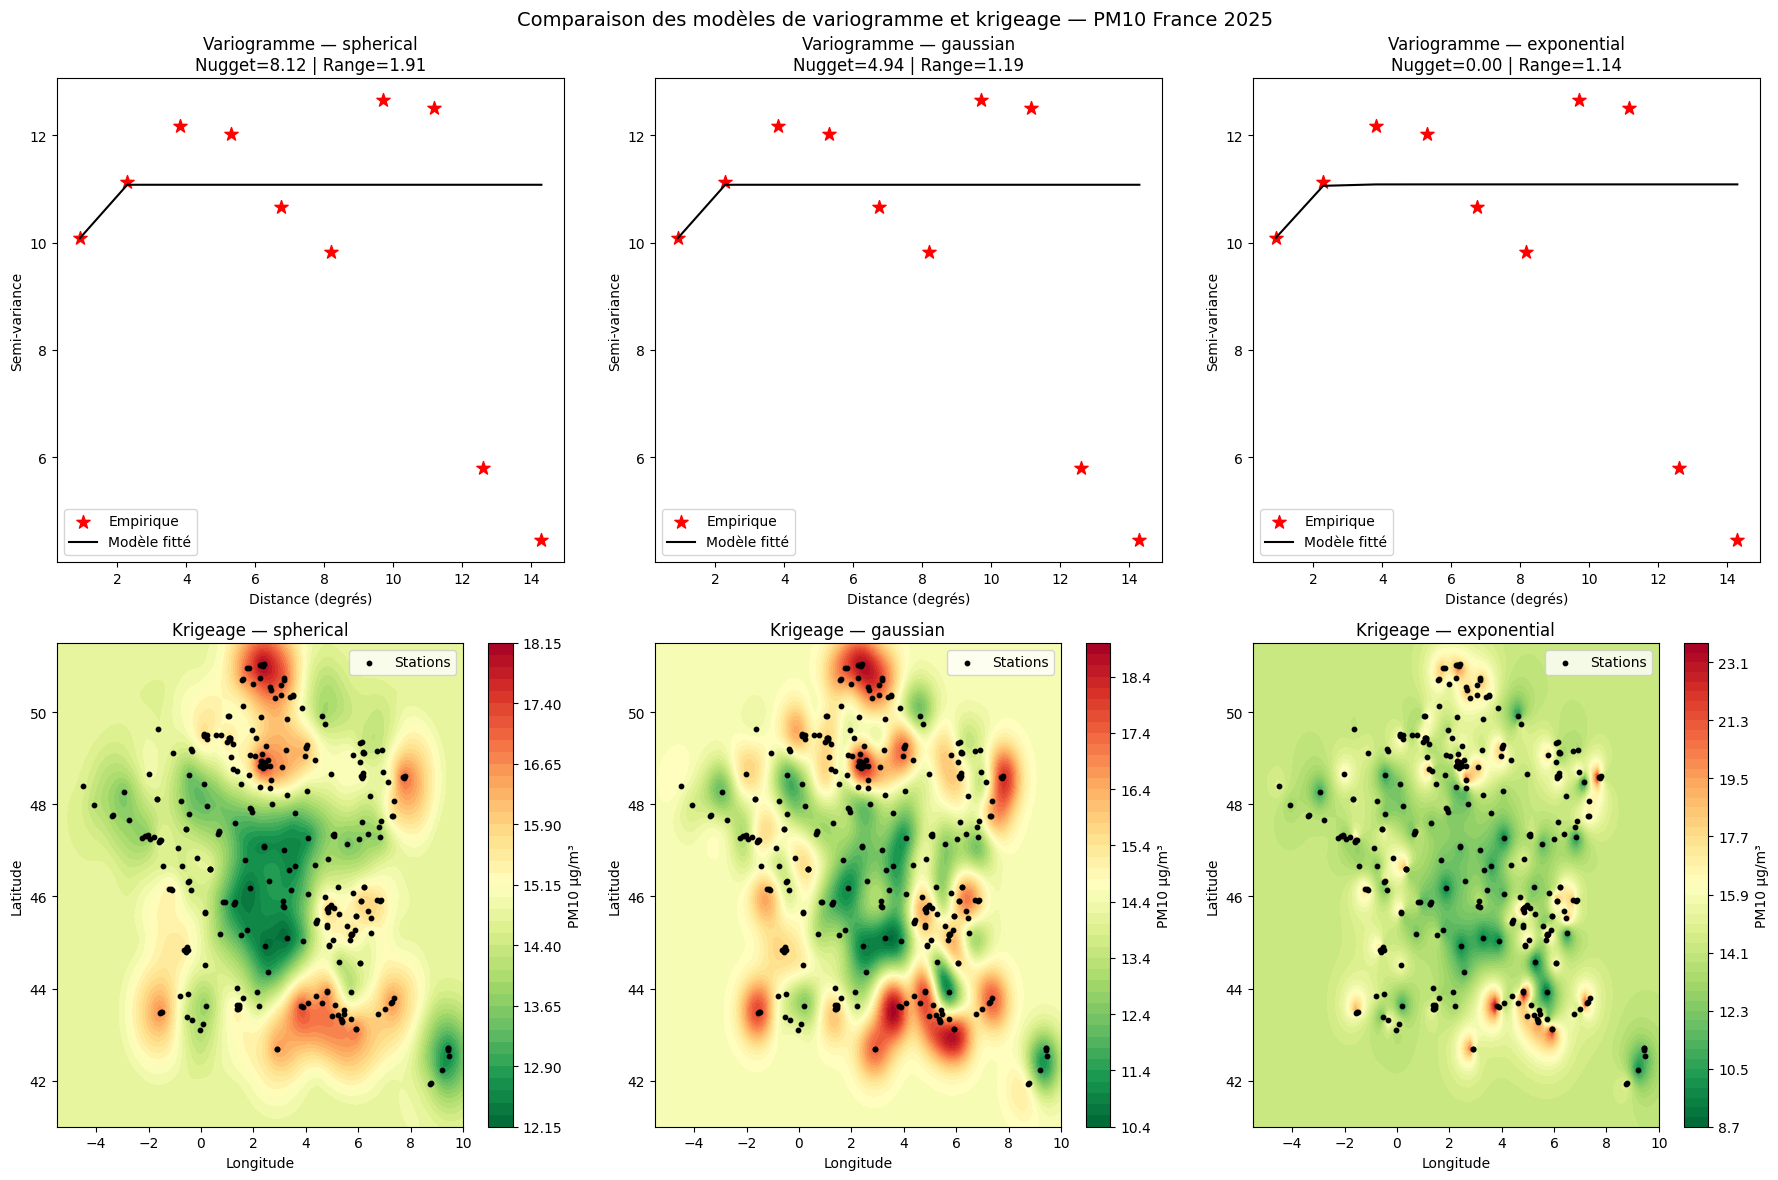

In [ ]:
modeles = ["spherical", "gaussian", "exponential"]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

grid_lon = np.linspace(-5.5, 10.0, 100)
grid_lat = np.linspace(41.0, 51.5, 100)

lons = d_metro["Longitude"].values
lats = d_metro["Latitude"].values
vals = d_metro["valeur"].values

for col, modele in enumerate(modeles):
    OK = OrdinaryKriging(
        lons, lats, vals,
        variogram_model=modele,
        nlags=10,
        verbose=False,
        enable_plotting=False
    )
    
    # --- Ligne 1 : variogramme ---
    ax_vario = axes[0, col]
    lags = OK.lags
    semivariance = OK.semivariance
    variogram_model_points = OK.variogram_function(OK.variogram_model_parameters, lags)
    
    ax_vario.scatter(lags, semivariance, c="red", marker="*", s=100, label="Empirique")
    ax_vario.plot(lags, variogram_model_points, "k-", label="Modèle fitté")
    ax_vario.set_title(f"Variogramme — {modele}\nNugget={OK.variogram_model_parameters[2]:.2f} | Range={OK.variogram_model_parameters[1]:.2f}")
    ax_vario.set_xlabel("Distance (degrés)")
    ax_vario.set_ylabel("Semi-variance")
    ax_vario.legend()

    # --- Ligne 2 : carte krigeage ---
    z, variance = OK.execute("grid", grid_lon, grid_lat)
    
    ax_map = axes[1, col]
    cf = ax_map.contourf(grid_lon, grid_lat, z, levels=50, cmap="RdYlGn_r")
    ax_map.scatter(lons, lats, c="black", s=10, label="Stations")
    plt.colorbar(cf, ax=ax_map, label="PM10 µg/m³")
    ax_map.set_title(f"Krigeage — {modele}")
    ax_map.set_xlabel("Longitude")
    ax_map.set_ylabel("Latitude")
    ax_map.legend()

plt.suptitle("Comparaison des modèles de variogramme et krigeage — PM10 France 2025", fontsize=14)
plt.tight_layout()
plt.show()

### Anisotrope

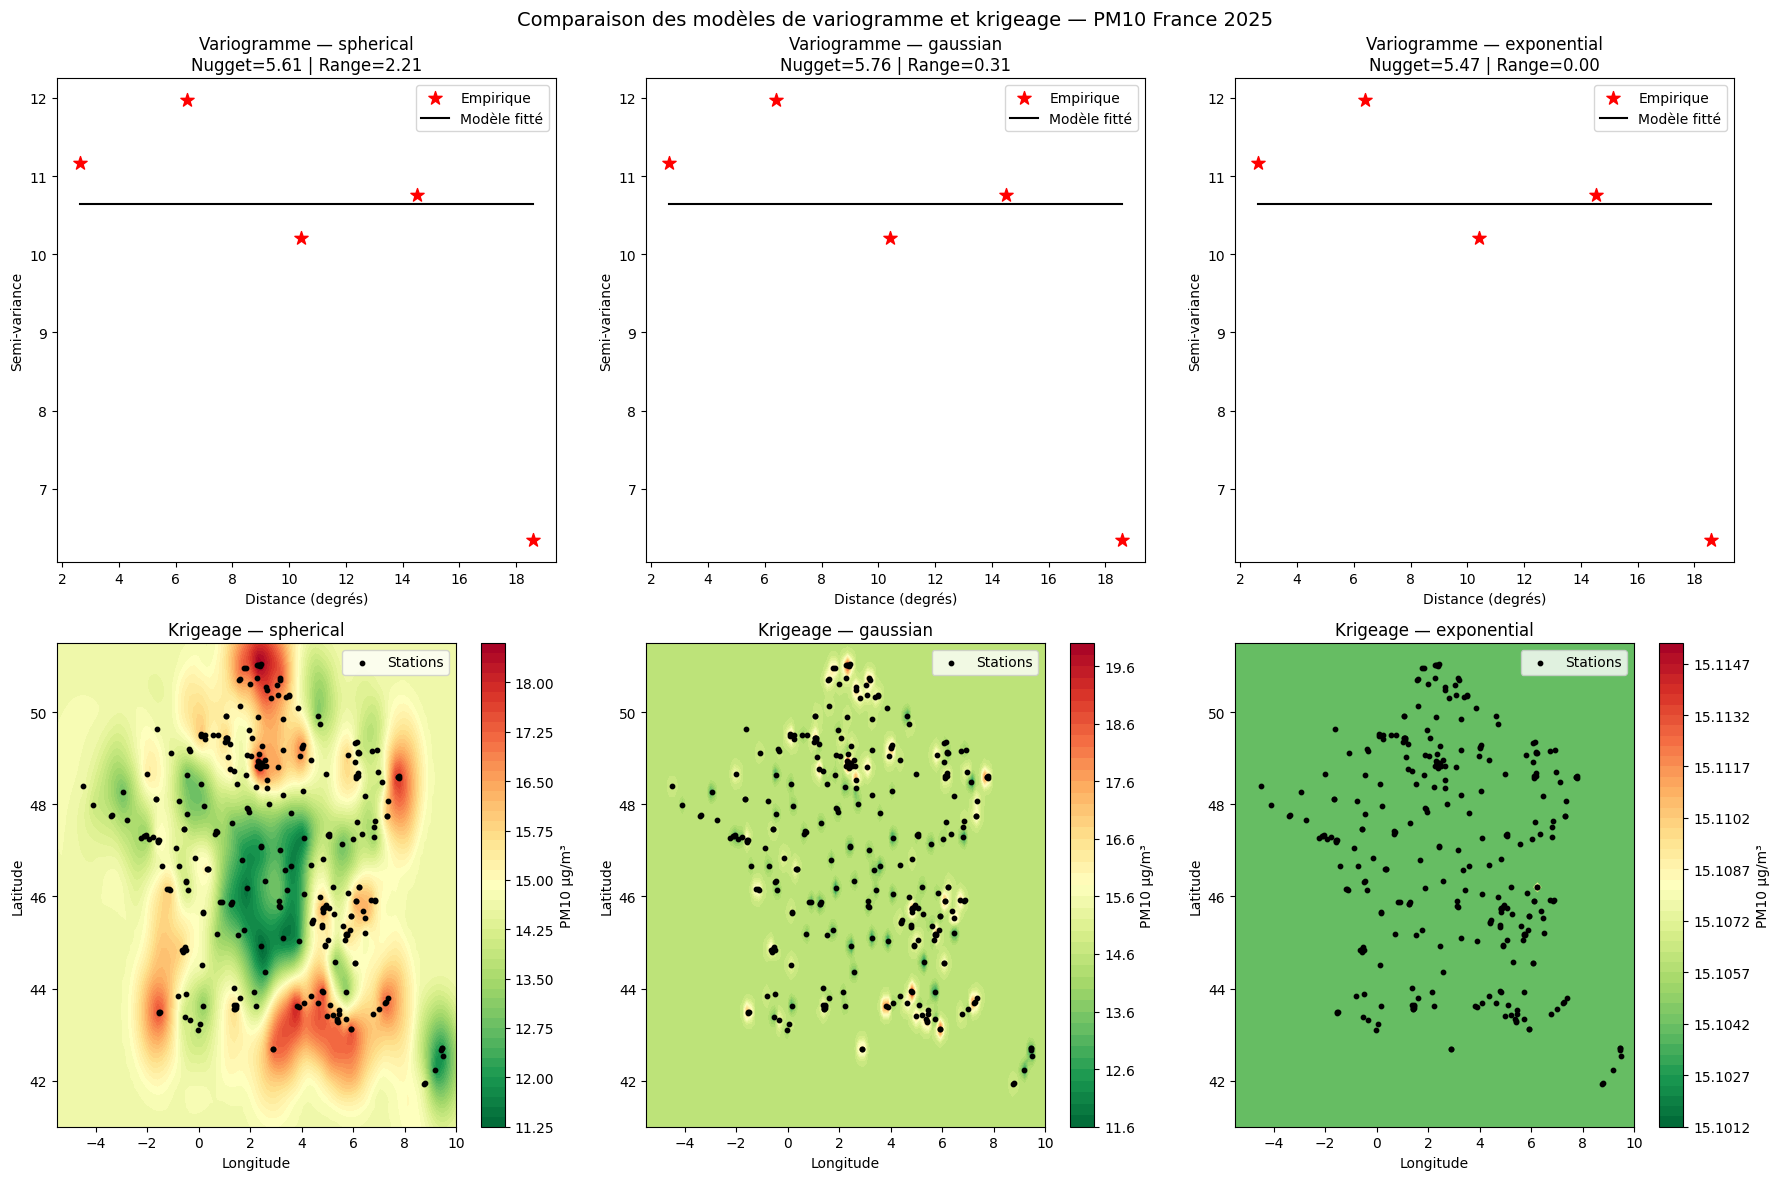

In [10]:
modeles = ["spherical", "gaussian", "exponential"]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

grid_lon = np.linspace(-5.5, 10.0, 100)
grid_lat = np.linspace(41.0, 51.5, 100)

lons = d_metro["Longitude"].values
lats = d_metro["Latitude"].values
vals = d_metro["valeur"].values

for col, modele in enumerate(modeles):
    OK = OrdinaryKriging(
        lons, lats, vals,
        variogram_model=modele,
        nlags=5,
        anisotropy_scaling=1.5,  # ratio des portées
        anisotropy_angle=90      # direction principale
    )
    
    # --- Ligne 1 : variogramme ---
    ax_vario = axes[0, col]
    lags = OK.lags
    semivariance = OK.semivariance
    variogram_model_points = OK.variogram_function(OK.variogram_model_parameters, lags)
    
    ax_vario.scatter(lags, semivariance, c="red", marker="*", s=100, label="Empirique")
    ax_vario.plot(lags, variogram_model_points, "k-", label="Modèle fitté")
    ax_vario.set_title(f"Variogramme — {modele}\nNugget={OK.variogram_model_parameters[2]:.2f} | Range={OK.variogram_model_parameters[1]:.2f}")
    ax_vario.set_xlabel("Distance (degrés)")
    ax_vario.set_ylabel("Semi-variance")
    ax_vario.legend()

    # --- Ligne 2 : carte krigeage ---
    z, variance = OK.execute("grid", grid_lon, grid_lat)
    
    ax_map = axes[1, col]
    cf = ax_map.contourf(grid_lon, grid_lat, z, levels=50, cmap="RdYlGn_r")
    ax_map.scatter(lons, lats, c="black", s=10, label="Stations")
    plt.colorbar(cf, ax=ax_map, label="PM10 µg/m³")
    ax_map.set_title(f"Krigeage — {modele}")
    ax_map.set_xlabel("Longitude")
    ax_map.set_ylabel("Latitude")
    ax_map.legend()

plt.suptitle("Comparaison des modèles de variogramme et krigeage — PM10 France 2025", fontsize=14)
plt.tight_layout()
plt.show()

## Validation croisée

### Isotrope

In [ ]:
resultats = {}

for nlags in range(5, 21):
    resultats[nlags] = {}
    for modele in ["spherical", "gaussian", "exponential"]:
        predicted = []
        for i in range(len(lons)):
            lons_cv = np.delete(lons, i)
            lats_cv = np.delete(lats, i)
            vals_cv = np.delete(vals, i)
            OK_cv = OrdinaryKriging(
                lons_cv, lats_cv, vals_cv,
                variogram_model=modele,
                nlags=nlags,
                verbose=False,
                enable_plotting=False
            )
            z, _ = OK_cv.execute("points", [lons[i]], [lats[i]])
            predicted.append(z[0])

        rmse = np.sqrt(np.mean((vals - np.array(predicted))**2))
        mae = np.mean(np.abs(vals - np.array(predicted)))
        resultats[nlags][modele] = {"RMSE": rmse, "MAE": mae}

# Affichage
print(f"{'nlags':<8} {'Modèle':<14} {'RMSE':>10} {'MAE':>10}")
print("-" * 45)
for nlags, modeles in resultats.items():
    for modele, metrics in modeles.items():
        print(f"{nlags:<8} {modele:<14} {metrics['RMSE']:>10.3f} {metrics['MAE']:>10.3f}")
    print()

nlags    Modèle               RMSE        MAE
---------------------------------------------
5        spherical           3.059      2.262
5        gaussian            3.144      2.320
5        exponential         3.498      2.629

6        spherical           3.067      2.264
6        gaussian            3.135      2.313
6        exponential         3.478      2.618

7        spherical           3.118      2.321
7        gaussian            3.981      2.581
7        exponential         3.471      2.617

8        spherical           3.118      2.316
8        gaussian            3.108      2.291
8        exponential         3.431      2.592

9        spherical           3.091      2.304
9        gaussian            3.232      2.407
9        exponential         3.451      2.605

10       spherical           3.084      2.263
10       gaussian            3.201      2.356
10       exponential         3.422      2.591

11       spherical           3.158      2.369
11       gaussian           

In [ ]:
# Construire le dataframe
rows = []
for nlags, modeles in resultats.items():
    for modele, metrics in modeles.items():
        rows.append({"nlags": nlags, "modele": modele, "RMSE": metrics["RMSE"], "MAE": metrics["MAE"]})

df_resultats = pd.DataFrame(rows)

# Classement par RMSE
df_classement = df_resultats.sort_values("RMSE").reset_index(drop=True)
df_classement.index += 1
df_classement.columns = ["nlags", "Modèle", "RMSE", "MAE"]

print("TOP 10 — classement par RMSE")
print(df_classement.head(10).to_string())

print("\nMeilleur nlags par modèle :")
print(df_resultats.loc[df_resultats.groupby("modele")["RMSE"].idxmin()].to_string(index=False))

TOP 10 — classement par RMSE
    nlags       Modèle      RMSE       MAE
1       5    spherical  3.059044  2.262278
2       6    spherical  3.067429  2.264300
3      10    spherical  3.084015  2.263255
4       9    spherical  3.091176  2.304088
5      14  exponential  3.101697  2.291542
6       8     gaussian  3.107752  2.290505
7      15  exponential  3.111054  2.308335
8      14    spherical  3.111517  2.320994
9      13  exponential  3.116941  2.345105
10      8    spherical  3.117592  2.316095

Meilleur nlags par modèle :
 nlags      modele     RMSE      MAE
    14 exponential 3.101697 2.291542
     8    gaussian 3.107752 2.290505
     5   spherical 3.059044 2.262278


### Anisotrope

In [11]:
resultats = {}

for nlags in range(5, 21):
    resultats[nlags] = {}
    for modele in ["spherical", "gaussian", "exponential"]:
        predicted = []
        for i in range(len(lons)):
            lons_cv = np.delete(lons, i)
            lats_cv = np.delete(lats, i)
            vals_cv = np.delete(vals, i)
            OK_cv = OrdinaryKriging(
                lons_cv, lats_cv, vals_cv,
                variogram_model=modele,
                nlags=nlags,
                anisotropy_scaling=1.5,  # ratio des portées
                anisotropy_angle=90      # direction principale
            )
            z, _ = OK_cv.execute("points", [lons[i]], [lats[i]])
            predicted.append(z[0])

        rmse = np.sqrt(np.mean((vals - np.array(predicted))**2))
        mae = np.mean(np.abs(vals - np.array(predicted)))
        resultats[nlags][modele] = {"RMSE": rmse, "MAE": mae}

# Affichage
print(f"{'nlags':<8} {'Modèle':<14} {'RMSE':>10} {'MAE':>10}")
print("-" * 45)
for nlags, modeles in resultats.items():
    for modele, metrics in modeles.items():
        print(f"{nlags:<8} {modele:<14} {metrics['RMSE']:>10.3f} {metrics['MAE']:>10.3f}")
    print()

nlags    Modèle               RMSE        MAE
---------------------------------------------
5        spherical           3.074      2.260
5        gaussian            3.087      2.324
5        exponential         3.212      2.408

6        spherical           3.071      2.265
6        gaussian            3.176      2.416
6        exponential         3.160      2.383

7        spherical           3.154      2.388
7        gaussian            3.185      2.424
7        exponential         3.182      2.390

8        spherical           3.106      2.306
8        gaussian            3.136      2.422
8        exponential         3.235      2.435

9        spherical           3.127      2.316
9        gaussian            3.183      2.398
9        exponential         3.222      2.432

10       spherical           3.131      2.324
10       gaussian            3.303      2.408
10       exponential         3.440      2.595

11       spherical           3.120      2.324
11       gaussian           

In [13]:
rows = []
for nlags, modeles in resultats.items():
    for modele, metrics in modeles.items():
        rows.append({"nlags": nlags, "modele": modele, "RMSE": metrics["RMSE"], "MAE": metrics["MAE"]})

df_resultats = pd.DataFrame(rows)

# Classement par RMSE
df_classement = df_resultats.sort_values("RMSE").reset_index(drop=True)
df_classement.index += 1
df_classement.columns = ["nlags", "Modèle", "RMSE", "MAE"]

print("TOP 10 — classement par RMSE")
print(df_classement.head(10).to_string())

print("\nMeilleur nlags par modèle :")
print(df_resultats.loc[df_resultats.groupby("modele")["RMSE"].idxmin()].to_string(index=False))

TOP 10 — classement par RMSE
    nlags     Modèle      RMSE       MAE
1       6  spherical  3.071223  2.264948
2       5  spherical  3.073728  2.260497
3       5   gaussian  3.086811  2.324129
4       8  spherical  3.106190  2.305792
5      16  spherical  3.110183  2.339155
6      15  spherical  3.112092  2.345755
7      11  spherical  3.120326  2.323555
8      12  spherical  3.126327  2.329348
9      19  spherical  3.126505  2.345271
10      9  spherical  3.126865  2.315751

Meilleur nlags par modèle :
 nlags      modele     RMSE      MAE
     6 exponential 3.159744 2.382854
     5    gaussian 3.086811 2.324129
     6   spherical 3.071223 2.264948
